In [1]:
from mfgp.models import GPDFC_General, GPDF_General, NARGP_General#, SVGPLayer, NARDGPLayer, DGPDFLayer, DGPDFCLayer
from mfgp.models.bmgp import AR1
from mfgp.models.dgp import SVGPLayer, NARDGPLayer, DGPDFLayer, DGPDFCLayer
from copy import deepcopy
import mfgp.data.exampleCurves1D as ex1D
import mfgp.data.exampleCurves3F as ex3F
import numpy as np
import tensorflow as tf
import gpflow
from gpflow.config import default_float, default_jitter
from mfgp.adaptation_maximizers import AbstractMaximizer, ScipyDirectMaximizer
import matplotlib.pyplot as plt
from matplotlib import rc
from inspect import getmembers, isfunction
from sklearn.metrics import mean_squared_error
from tqdm import trange, tqdm

Fortran code not compiled, module not functional


In [ ]:
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize
from sklearn import preprocessing

In [2]:
def create_model_nonlinear_gp(method_name, input_dim, f_list, init_X, num_derivative, tau, lower_bound, upper_bound, maximiser,
                             eps=1e-6, expected_acq_fn: bool=False, monte_carlo_prediction=False, surrogate_lowest_fidelity=True):
    model = None 
    if method_name == "NARGP":
        model = NARGP_General(input_dim, f_list, init_X, lower_bound, upper_bound, maximiser, 
                              eps=eps, expected_acq_fn=expected_acq_fn, monte_carlo_prediction=monte_carlo_prediction,
                              surrogate_lowest_fidelity=surrogate_lowest_fidelity)
    elif method_name == "GPDF":
        model = GPDF_General(input_dim, num_derivative, tau, f_list, init_X, lower_bound, upper_bound, maximiser, 
                             eps=eps, expected_acq_fn=expected_acq_fn, monte_carlo_prediction=monte_carlo_prediction,
                             surrogate_lowest_fidelity=surrogate_lowest_fidelity)
    elif method_name == "GPDFC":
        model = GPDFC_General(input_dim, num_derivative, tau, f_list, init_X, lower_bound, upper_bound, maximiser, 
                              eps=eps, expected_acq_fn=expected_acq_fn, monte_carlo_prediction=monte_carlo_prediction,
                              surrogate_lowest_fidelity=surrogate_lowest_fidelity)
    else:
        raise ValueError("Wrong method name")
    return model

def create_model_linear_gp(input_dim, f_list, lower_bound, upper_bound, X_train_low, X_train_high, Y_train_low, Y_train_high):
    tf.config.run_functions_eagerly(True)
    X_train_high_tensor = tf.convert_to_tensor(deepcopy(X_train_high), dtype=default_float())
    X_train_low_tensor = tf.convert_to_tensor(deepcopy(X_train_low), dtype=default_float())   
    Y_train_high_tensor = tf.convert_to_tensor(deepcopy(Y_train_high), dtype=default_float())
    Y_train_low_tensor = tf.convert_to_tensor(deepcopy(Y_train_low), dtype=default_float())
    model = AR1(input_dim, f_list, lower_bound, upper_bound)
    model.set_training_data([X_train_low_tensor, X_train_high_tensor], [Y_train_low_tensor, Y_train_high_tensor])
    model.fit()
    model.ARD()
    return model

def create_model_deep_gp(method_name, input_dim, f_list, X_train_low, X_train_high, Y_train_low, Y_train_high,
                         num_delays, tau, lower_bound, upper_bound, maximiser,
                         eps=1e-6, expected_acq_fn: bool=False):
    num_low, num_high = len(Y_train_low), len(Y_train_high)
    X_train_high_tensor = tf.convert_to_tensor(X_train_high, dtype=default_float())
    X_train_low_tensor = tf.convert_to_tensor(X_train_low, dtype=default_float())   
    Y_train_high_tensor = tf.convert_to_tensor(Y_train_high, dtype=default_float())
    Y_train_low_tensor = tf.convert_to_tensor(Y_train_low, dtype=default_float())
    num_inducing_low, num_inducing_high = int(num_low/2), int(num_high/2)
    Z_low = tf.linspace(lower_bound[0], upper_bound[0], num_inducing_low)[:, None]
    kernel_low = gpflow.kernels.SquaredExponential()
    likelihood_low = gpflow.likelihoods.Gaussian(variance=1e-4)
    likelihood_high = gpflow.likelihoods.Gaussian(variance=1e-4)
    first_layer = SVGPLayer(f_list[0], input_dim, kernel_low, likelihood_low, Z_low, lower_bound, upper_bound, whiten=False)
    first_layer.set_data(X_train_low_tensor, Y_train_low_tensor)
    first_layer.train()
    first_layer.set_all_training_status_variables(False)
    second_layer = None 
    if method_name == "NARDGP":
        second_layer = NARDGPLayer(f_list[1], input_dim, likelihood_high, num_inducing_high, lower_bound, upper_bound,
                                   first_layer)
    elif method_name == "DGPDF":
        second_layer = DGPDFLayer(f_list[1], input_dim, likelihood_high, num_inducing_high, lower_bound, upper_bound,
                                    first_layer, num_delays=num_delays, tau=tau)
    elif method_name == "DGPDFC":
        second_layer = DGPDFCLayer(f_list[1], input_dim, likelihood_high, num_inducing_high, lower_bound, upper_bound,
                                   first_layer, num_delays=num_delays, tau=tau)
    else:
        raise ValueError("Wrong method name")
    gpflow.utilities.set_trainable(likelihood_high.variance, False)
    second_layer.set_data(X_train_high_tensor, Y_train_high_tensor)
    second_layer.train()
    return first_layer, second_layer

def plot_predictions(mean, var, X, method_name):
    std = np.atleast_2d(np.sqrt(var))
    p = plt.plot(X, mean, label=method_name)
    plt.fill_between(X[:, 0], mean[:, 0] - 2 * std[:, 0], mean[:, 0] + 2 * std[:, 0], alpha=0.2, color=p[0].get_color())

def plot_actual(X, y):
    plt.plot(X, y, label="Actual curve")

In [12]:
#list all functions
all_curves = [x[0] for x in getmembers(ex1D, isfunction)]
# setup errors
errors = {}
# hyperparameters
num_lf, num_hf = 50, 10
lower, upper = 0, 1
num_delays, tau = 1, 0.01
dim = 1
errors["NARGP"] = []
errors["GPDF"] = []
errors["GPDFC"] = []
errors["NARDGP"] = []
errors["DGPDF"] = []
errors["DGPDFC"] = []
errors["AR1"] = []

green = "\033[32;20;53m"
bar_format = f"{green}{{l_bar}}{{bar:50}} [{{elapsed}}]{{r_bar}}"
for curve_name in tqdm(all_curves, bar_format=bar_format, leave = True):
    X_train_hf, X_train_lf, y_train_lf, f_high, f_low, X_test, y_test, y_train_hf = getattr(ex1D, curve_name)(num_hf, num_lf)

    nargp = create_model_nonlinear_gp("NARGP", dim, [f_low, f_high], [X_train_lf, X_train_hf], 
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    mean_nargp, var_nargp = nargp.predict(X_test)
    errors["NARGP"].append(mean_squared_error(mean_nargp, y_test))

    gpdf = create_model_nonlinear_gp("GPDF", dim, [f_low, f_high], [X_train_lf, X_train_hf], 
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    mean_gpdf, var_gpdf = gpdf.predict(X_test)
    errors["GPDF"].append(mean_squared_error(mean_gpdf, y_test))

    gpdfc = create_model_nonlinear_gp("GPDFC", dim, [f_low, f_high], [X_train_lf, X_train_hf], 
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    mean_gpdfc, var_gpdfc = gpdfc.predict(X_test)
    errors["GPDFC"].append(mean_squared_error(mean_gpdfc, y_test))
    
    _, nardgp = create_model_deep_gp("NARDGP", dim, [f_low, f_high], X_train_lf, X_train_hf, y_train_lf, y_train_hf,
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    nardgp_mean, nardgp_var = nardgp.predict(X_test)
    errors["NARDGP"].append(mean_squared_error(nardgp_mean, y_test))
    
    _, dgpdf = create_model_deep_gp("DGPDF", dim, [f_low, f_high], X_train_lf, X_train_hf, y_train_lf, y_train_hf,
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    dgpdf_mean, dgpdf_var = dgpdf.predict(X_test)
    errors["DGPDF"].append(mean_squared_error(dgpdf_mean, y_test))
    
    _, dgpdfc = create_model_deep_gp("DGPDFC", dim, [f_low, f_high], X_train_lf, X_train_hf, y_train_lf, y_train_hf,
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    dgpdfc_mean, dgpdfc_var = dgpdfc.predict(X_test)
    errors["DGPDFC"].append(mean_squared_error(dgpdfc_mean, y_test))
    
    ar1 = create_model_linear_gp(dim, [f_low, f_high], lower, upper, X_train_lf, X_train_hf, y_train_lf, y_train_hf)
    mean_ar1, var_ar1 = ar1.predict(X_test)
    errors["AR1"].append(mean_squared_error(mean_ar1, y_test))


  0%|                                                   [00:00]| 0/12 [00:00<?, ?it/s]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


  8%|████▏                                              [13:44]| 1/12 [13:44<2:31:08, 824.43s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


 17%|████████▎                                          [27:35]| 2/12 [27:35<2:18:01, 828.13s/it]

...

 83%|█████████████████████████████████████████▋         [2:04:41]| 10/12 [2:04:41<21:52, 656.24s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


 92%|█████████████████████████████████████████████▊     [2:16:58]| 11/12 [2:16:58<11:21, 681.03s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


100%|██████████████████████████████████████████████████ [2:29:20]| 12/12 [2:29:20<00:00, 746.68s/it]


  0%|                                                   [00:00]| 0/12 [00:00<?, ?it/s]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


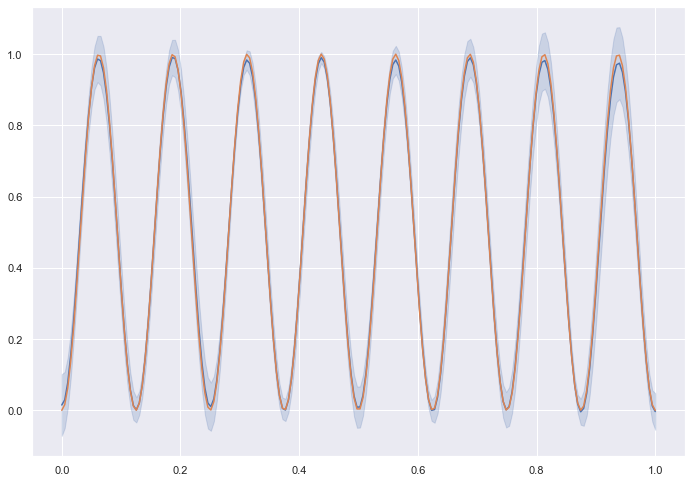

  8%|████▏                                              [03:22]| 1/12 [03:22<37:11, 202.86s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


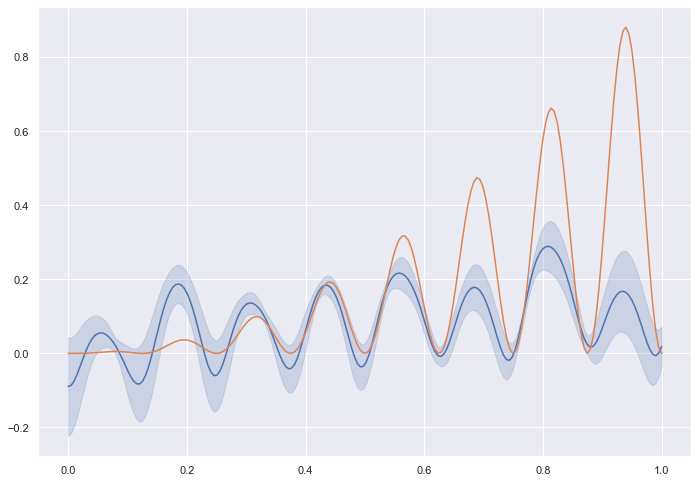

 17%|████████▎                                          [06:00]| 2/12 [06:00<29:24, 176.47s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


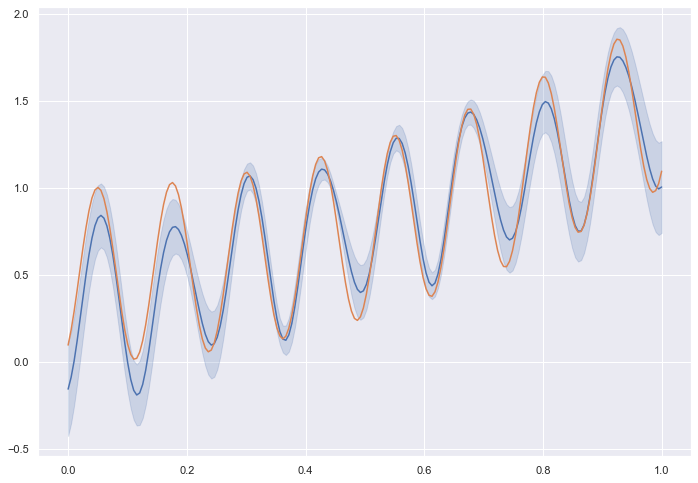

 25%|████████████▌                                      [09:02]| 3/12 [09:02<26:47, 178.66s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


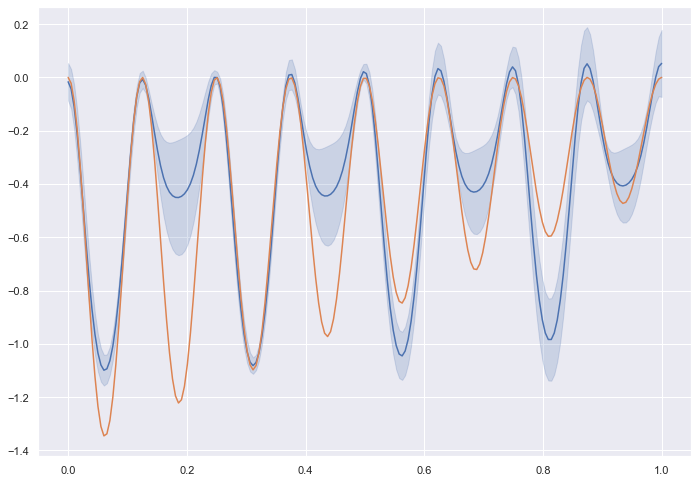

 33%|████████████████▋                                  [12:24]| 4/12 [12:24<25:05, 188.19s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


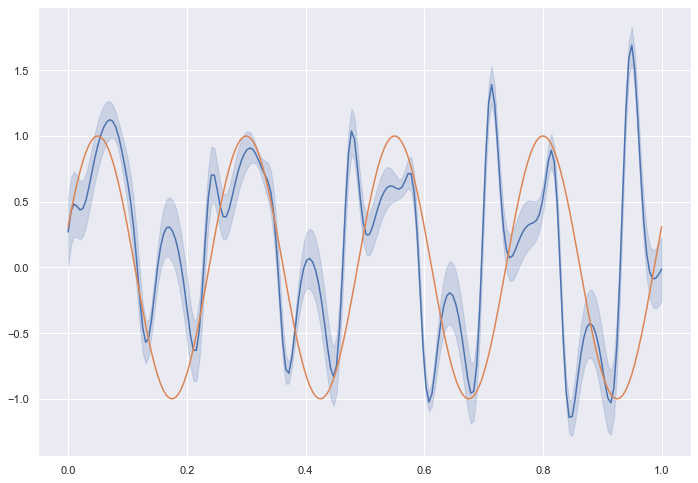

 42%|████████████████████▊                              [15:48]| 5/12 [15:48<22:34, 193.56s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


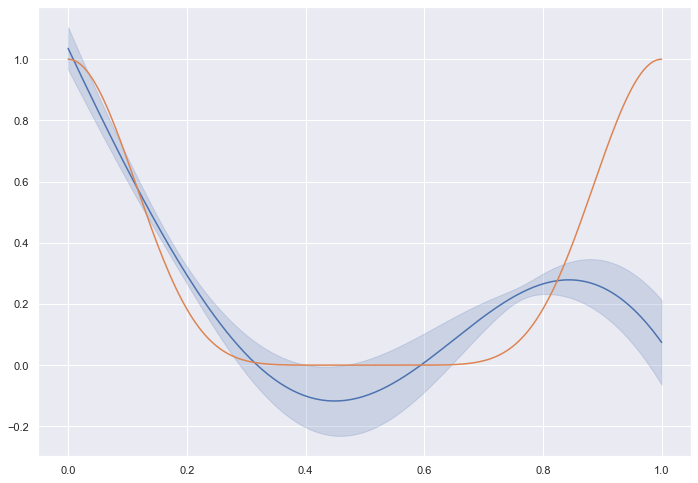

 50%|█████████████████████████                          [18:59]| 6/12 [18:59<19:17, 192.98s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


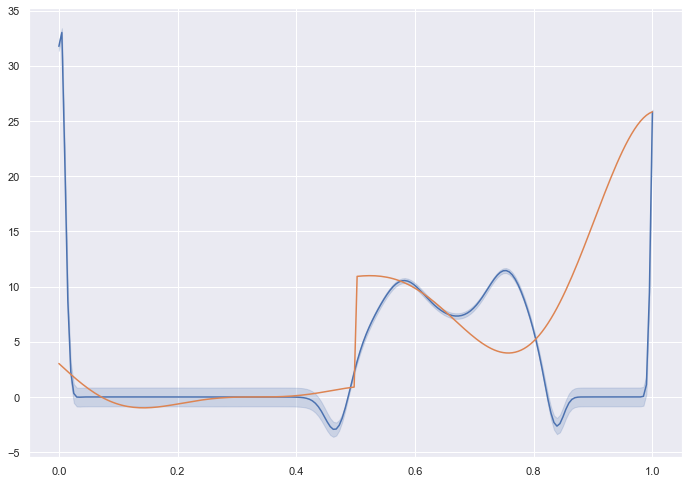

 58%|█████████████████████████████▏                     [22:39]| 7/12 [22:39<16:48, 201.69s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


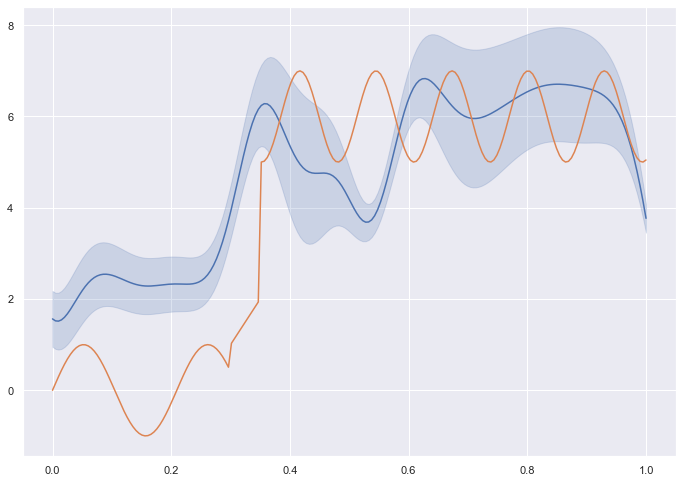

 67%|█████████████████████████████████▎                 [24:37]| 8/12 [24:37<11:40, 175.13s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


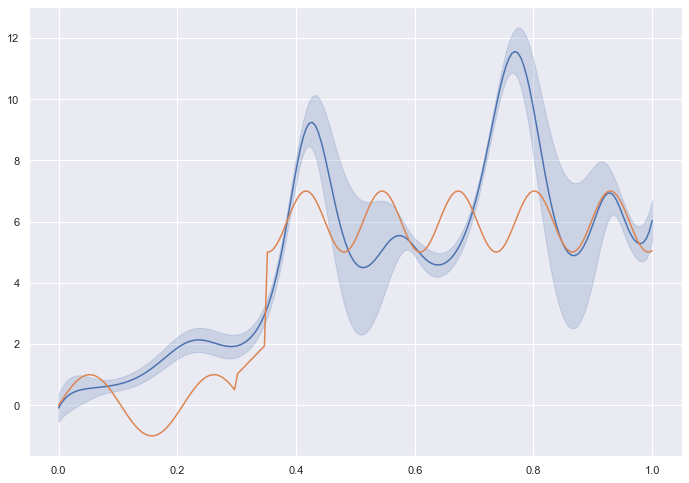

 75%|█████████████████████████████████████▌             [27:02]| 9/12 [27:02<08:16, 165.56s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


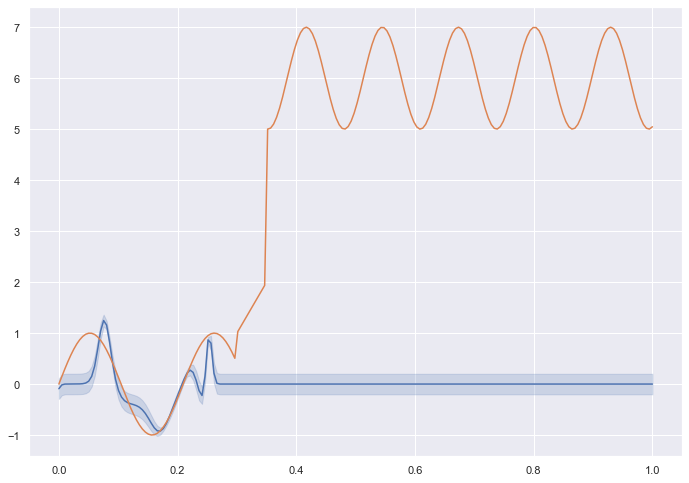

 83%|█████████████████████████████████████████▋         [30:01]| 10/12 [30:01<05:39, 169.86s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


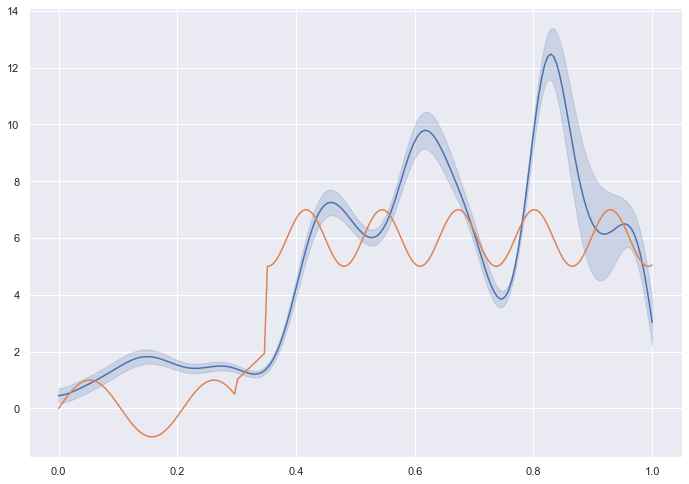

 92%|█████████████████████████████████████████████▊     [33:25]| 11/12 [33:25<03:00, 180.36s/it]

++++++++++++++Training++++++++++++++
++++++++++++++Training++++++++++++++


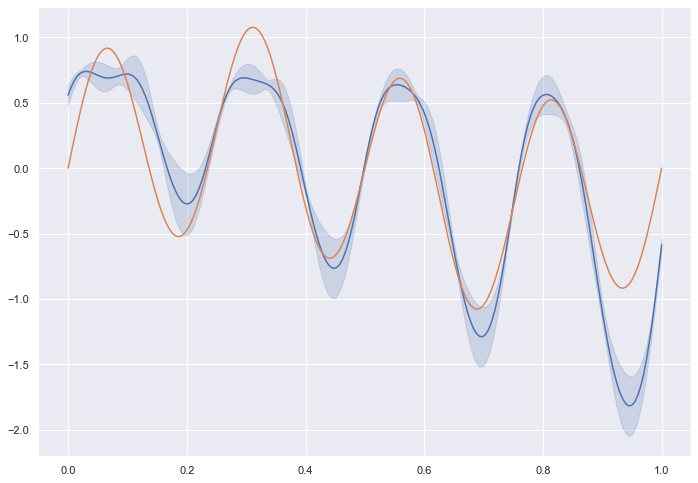

100%|██████████████████████████████████████████████████ [36:42]| 12/12 [36:42<00:00, 183.52s/it]


In [45]:
for curve_name in tqdm(all_curves, bar_format=bar_format, leave = True):
    X_train_hf, X_train_lf, y_train_lf, f_high, f_low, X_test, y_test, y_train_hf = getattr(ex1D, curve_name)(num_hf, num_lf)
    
    _, dgpdf = create_model_deep_gp("DGPDF", dim, [f_low, f_high], X_train_lf, X_train_hf, y_train_lf, y_train_hf,
                                        num_delays, tau, [lower], [upper], ScipyDirectMaximizer(), eps=1e-6)
    dgpdf_mean, dgpdf_var = dgpdf.predict(X_test)

    plot_predictions(dgpdf_mean, dgpdf_var, X_test, "DGPDF")
    plot_actual(X_test, y_test)    
    plt.show()

In [19]:
[x[4:] for x in all_curves]

['curve1',
 'curve2',
 'curve3',
 'curve4',
 'curve5',
 'curve6',
 'discontinuity1',
 'discontinuity2',
 'discontinuity3',
 'discontinuity4',
 'discontinuity5',
 'linear_curve1']

In [13]:
import pandas as pd
errors_df = pd.DataFrame(errors)

In [25]:
errors_df.index = [x[4:] for x in all_curves]

In [26]:
errors_df

,NARGP,GPDF,GPDFC,NARDGP,DGPDF,DGPDFC,AR1
curve1,0.000015,0.000462,0.000462,0.000084,0.000211,0.000172,2.061164e-01
curve2,0.048377,0.046837,0.046837,0.049839,0.050847,0.049809,1.768548e-01
curve3,0.146093,0.060923,0.060923,0.179858,0.026267,0.049376,3.465304e-01
curve4,0.013794,0.046383,0.046383,0.046549,0.031696,0.088879,3.060050e-01
curve5,0.416350,0.189896,0.189896,0.332981,0.094258,0.344452,4.826696e-01
curve6,0.001553,0.001546,0.001546,0.006308,0.024069,0.008319,5.066211e-03
discontinuity1,1.259589,1.258721,1.258721,16.486855,63.813244,10.292861,5.356976e+00
discontinuity2,0.029352,0.029352,0.029352,3.607689,2.772833,0.886635,3.254361e-02
discontinuity3,0.035921,0.035907,0.035907,1.357656,5.541015,1.290740,1.472097e-01
discontinuity4,0.034805,0.034763,0.034763,1.815605,22.354429,3.850239,4.588529e-01


<AxesSubplot:>

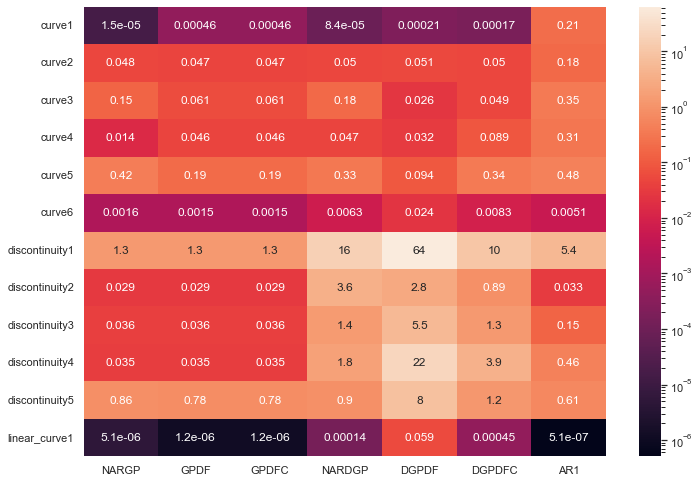

In [32]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(errors_df, annot=True, norm=LogNorm())

<AxesSubplot:>

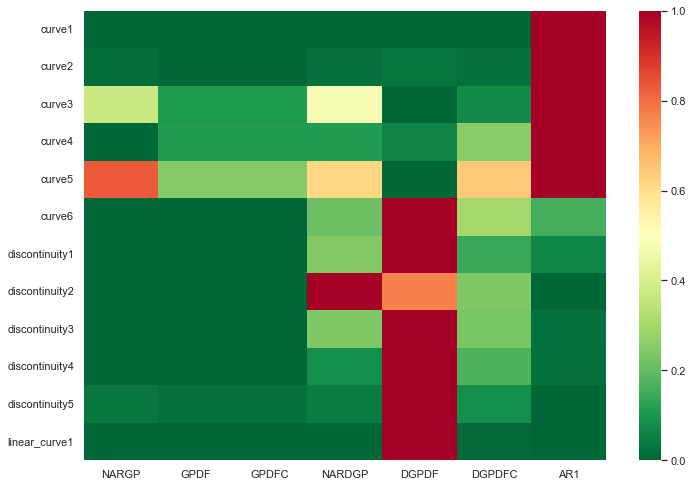

In [44]:
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(errors_df.values.transpose())
df = pd.DataFrame(x_scaled.transpose())
df.columns = errors_df.columns
df.index = errors_df.index
sns.diverging_palette(220, 20, as_cmap=True)
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(df, cmap="RdYlGn_r")